In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [3]:
# Configuraciones a probar
activaciones = ['relu', 'tanh', 'logistic']
capas = [(10,), (20,10), (30,20,10)]

resultados = []

for act in activaciones:
    for capa in capas:
        clf = MLPClassifier(hidden_layer_sizes=capa,
                            activation=act,
                            max_iter=10000,
                            random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        resultados.append({
            'activacion': act,
            'capas': capa,
            'accuracy': acc
        })

# Mostrar resultados
pd.DataFrame(resultados)


,activacion,capas,accuracy
0,relu,"(10,)",0.955556
1,relu,"(20, 10)",0.933333
2,relu,"(30, 20, 10)",0.933333
3,tanh,"(10,)",0.933333
4,tanh,"(20, 10)",0.933333
5,tanh,"(30, 20, 10)",0.888889
6,logistic,"(10,)",0.933333
7,logistic,"(20, 10)",0.933333
8,logistic,"(30, 20, 10)",0.911111


Accuracy: 0.9555555555555556

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



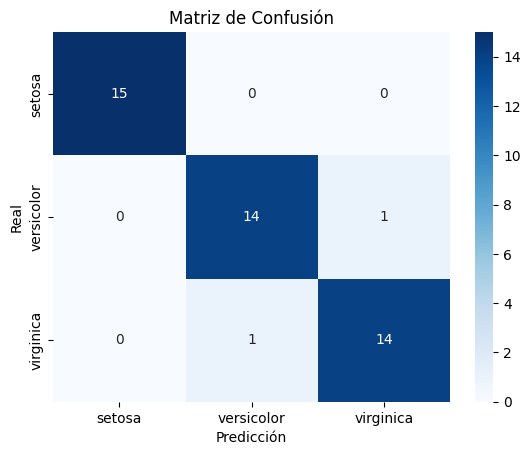

In [4]:
# Elegir la mejor configuración
mejor_modelo = MLPClassifier(hidden_layer_sizes=(10,),
                             activation='relu',
                             max_iter=10000,
                             random_state=42)
mejor_modelo.fit(X_train, y_train)
y_pred = mejor_modelo.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


In [5]:
train_acc = mejor_modelo.score(X_train, y_train)
test_acc = mejor_modelo.score(X_test, y_test)

print(f"Precisión en entrenamiento: {train_acc:.3f}")
print(f"Precisión en prueba: {test_acc:.3f}")


Precisión en entrenamiento: 0.971
Precisión en prueba: 0.956
